# Prediksi Kelulusan Mahasiswa (CRISP-DM Framework)
## Instalasi Library Tambahan
Karena dataset yang kita miliki **Imbalanced** (Terlalu banyak yang Lulus Tepat Waktu dibanding yang Terlambat), kita butuh library `imbalanced-learn` untuk menyeimbangkannya dengan teknik **SMOTE**.


In [67]:
!pip install imbalanced-learn



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Business Understanding
Tujuan dari notebook ini adalah membangun model machine learning untuk memprediksi apakah seorang mahasiswa akan lulus **Tepat Waktu** atau **Terlambat**. 
Metrik evaluasi utama yang akan digunakan adalah F1-Score dan ROC-AUC untuk mengukur keseimbangan antara *Precision* dan *Recall*.


In [68]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.base import clone

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier

# Handling Imbalanced Data
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler

# Evaluation Metrics & Visualization
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, log_loss, brier_score_loss, cohen_kappa_score, 
    confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.inspection import DecisionBoundaryDisplay

import joblib
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


## 2. Data Understanding & Exploratory Data Analysis (EDA)
Tahap ini memuat data dari `dataset_mahasiswa.csv` dan melakukan analisis untuk menemukan pola awal sebelum melakukan pemodelan.


In [69]:
DATA_PATH = 'dataset_mahasiswa.csv'
df = pd.read_csv(DATA_PATH)

# Bersihkan Spasi Kosong di Nama Kolom Target (Bila ada)
df.rename(columns=lambda x: x.strip(), inplace=True)
TARGET_COL = 'STATUS KELULUSAN'

print(f'Dimensi awal dataset: {df.shape}')
print(df.head())


Dimensi awal dataset: (145, 15)
                    NAMA JENIS KELAMIN STATUS MAHASISWA  UMUR   STATUS NIKAH  \
0                  UNAMA   LAKI - LAKI        MAHASISWA    24  BELUM MENIKAH   
1  LEYLA TRIYANA PRATIWI     PEREMPUAN        MAHASISWA    26  BELUM MENIKAH   
2  VERIS SOFIYAN PRAYOGA   LAKI - LAKI        MAHASISWA    29  BELUM MENIKAH   
3   ADITYA AKBAR NUGRAHA   LAKI - LAKI        MAHASISWA    27  BELUM MENIKAH   
4       ERNA EKA RIYANTI     PEREMPUAN        MAHASISWA    25  BELUM MENIKAH   

   IPS 1  IPS 2  IPS 3  IPS 4  IPS 5  IPS 6  IPS 7  IPS 8   IPK  \
0   3.17   2.70   3.23   2.41   3.00   2.47   1.75   0.00  2.75   
1   3.60   3.50   3.42   2.85   3.31   2.95   2.18    NaN  3.39   
2   2.67   2.66   2.93   3.14   2.92   2.64   2.88   0.50  2.81   
3   2.48   2.86   2.09   2.55   2.55   2.43   2.55   2.17  2.82   
4   3.19   3.08   3.31   2.83   3.36   2.73   3.06   0.00  3.09   

  STATUS KELULUSAN  
0            TEPAT  
1            TEPAT  
2            TEPAT  


### A. Univariate Analysis
**1. Distribusi Target Variabel (Status Kelulusan)**
Kita melihat apakah dataset seimbang (*balanced*) atau berat sebelah (*imbalanced*).


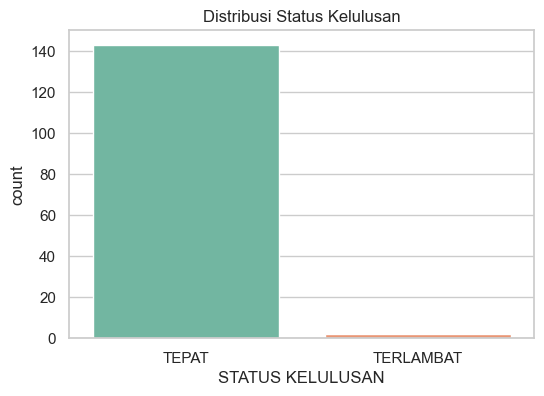

In [70]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET_COL, palette='Set2')
plt.title('Distribusi Status Kelulusan')
plt.show()


**2. Distribusi Fitur Numerik Utama (Umur & Nilai Awal)**
Melihat bentuk distribusi penyebaran Umur dan Nilai IPS Semester 1 mahasiswa.


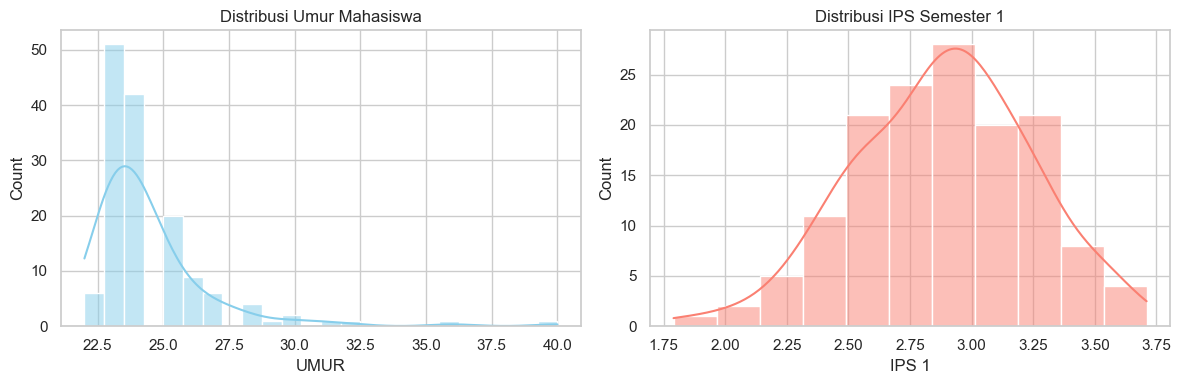

In [71]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x='UMUR', kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Distribusi Umur Mahasiswa')

if 'IPS 1' in df.columns:
    sns.histplot(data=df, x='IPS 1', kde=True, ax=ax[1], color='salmon')
    ax[1].set_title('Distribusi IPS Semester 1')
plt.tight_layout()
plt.show()


### B. Bivariate Analysis
**1. Hubungan Jenis Kelamin dengan Status Kelulusan**
Memeriksa apakah ada kecenderungan proporsi kelulusan terlambat yang lebih tinggi pada jenis kelamin tertentu.


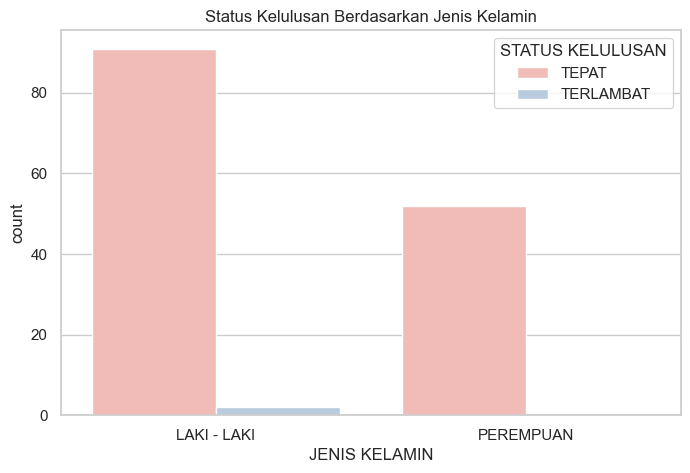

In [72]:
plt.figure(figsize=(8, 5))
if 'JENIS KELAMIN' in df.columns:
    sns.countplot(data=df, x='JENIS KELAMIN', hue=TARGET_COL, palette='Pastel1')
    plt.title('Status Kelulusan Berdasarkan Jenis Kelamin')
    plt.show()
else:
    print("Kolom JENIS KELAMIN tidak ditemukan.")


**2. Dampak Nilai Awal (IPS 1 & 2) terhadap Kelulusan**
Membandingkan rata-rata nilai semester awal antara mahasiswa yang lulus tepat waktu vs terlambat dengan Boxplot.


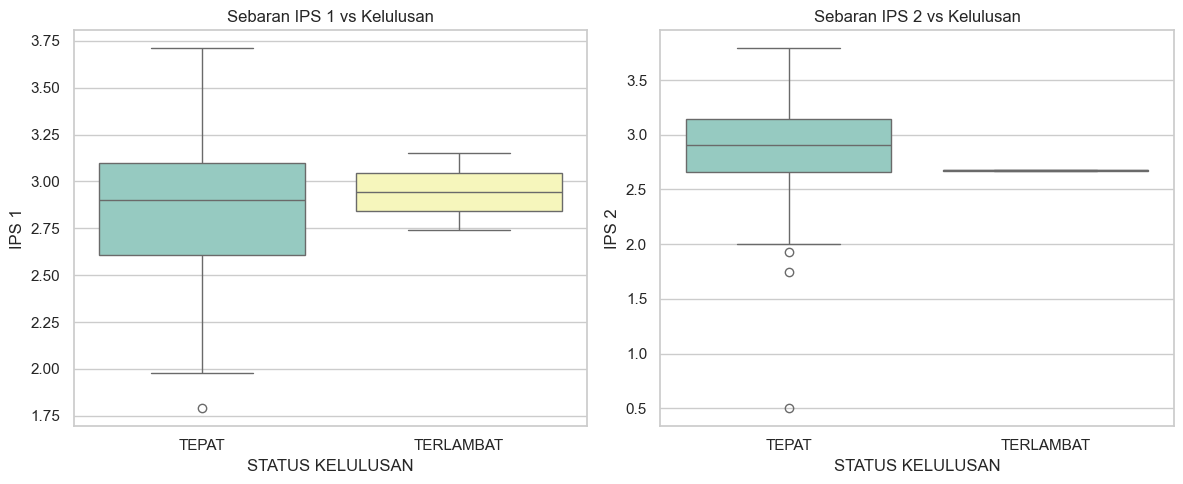

In [73]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

if 'IPS 1' in df.columns and 'IPS 2' in df.columns:
    sns.boxplot(data=df, x=TARGET_COL, y='IPS 1', ax=ax[0], palette='Set3')
    ax[0].set_title('Sebaran IPS 1 vs Kelulusan')
    
    sns.boxplot(data=df, x=TARGET_COL, y='IPS 2', ax=ax[1], palette='Set3')
    ax[1].set_title('Sebaran IPS 2 vs Kelulusan')

plt.tight_layout()
plt.show()


### C. Multivariate Analysis
**1. Heatmap Korelasi Nilai IPS**
Memeriksa korelasi antar nilai akademik (IPS 1 hingga IPS 6). Jika sangat berkorelasi kuat (>0.8), berarti ada indikasi *Multicollinearity*.


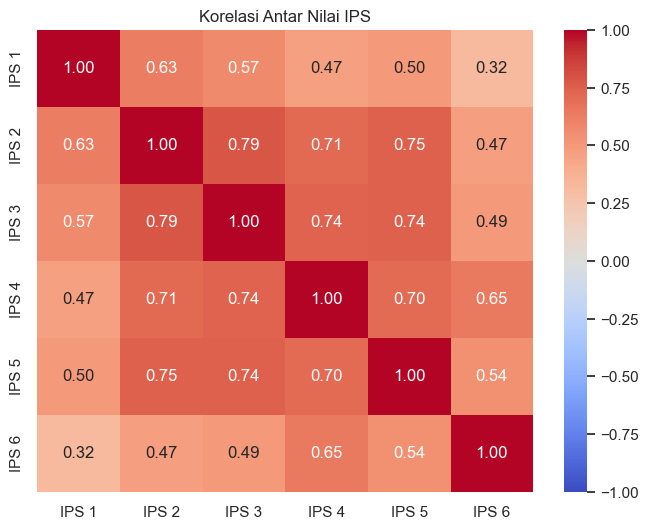

In [74]:
plt.figure(figsize=(8, 6))
ips_cols = [col for col in df.columns if 'IPS' in col and col not in ['IPS 7', 'IPS 8']]
if len(ips_cols) > 0:
    corr_matrix = df[ips_cols].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
    plt.title('Korelasi Antar Nilai IPS')
    plt.show()
else:
    print("Kolom IPS tidak ditemukan.")


**2. Pairplot Multivariat**
Memetakan persebaran data 3 dimensi (IPS 1, IPS 2, UMUR) sekaligus membedakan warnanya berdasarkan kelas target (Status Kelulusan).


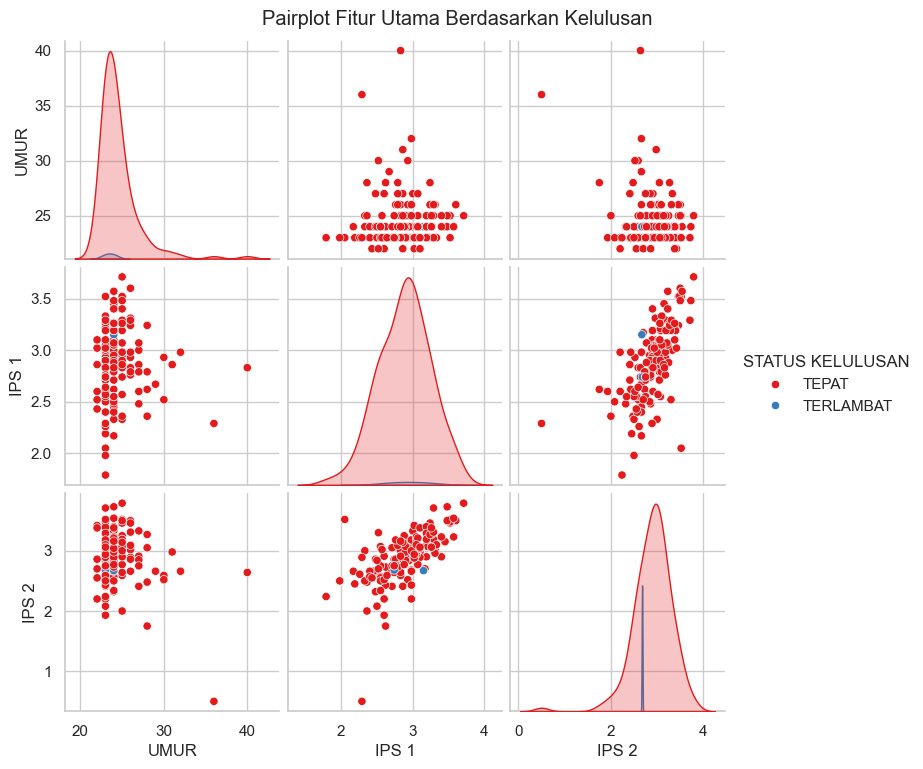

In [75]:
cols_to_pair = ['UMUR', 'IPS 1', 'IPS 2']
cols_to_pair = [col for col in cols_to_pair if col in df.columns]

if len(cols_to_pair) > 1:
    sns.pairplot(df[cols_to_pair + [TARGET_COL]], hue=TARGET_COL, palette='Set1', diag_kind='kde')
    plt.suptitle('Pairplot Fitur Utama Berdasarkan Kelulusan', y=1.02)
    plt.show()
else:
    print("Kolom untuk pairplot tidak lengkap.")


## 3. Data Preparation & Handling Imbalanced Data
- **Remove Data Leakage**: Membuang kolom `NAMA`, `IPS 7`, `IPS 8`, dan `IPK`.
- **Missing Values Handling**: Angka -> *Median*, Teks -> *Modus*.
- **Encoding**: `OneHotEncoder` untuk teks. `StandardScaler` untuk angka.
- **Handling Imbalanced Data**: Karena data mayoritas lulus Tepat Waktu, kita gunakan **SMOTE** untuk mensintesis data minoritas agar model belajar seimbang!
- **Data Splitting**: 80% Train, 20% Test (Stratified).


In [76]:
# Drop Leakage Columns
cols_to_drop = ['NAMA', 'IPS 7', 'IPS 8', 'IPK ', 'IPK']
df_prep = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')

X = df_prep.drop(columns=[TARGET_COL])
y_raw = df_prep[TARGET_COL]

target_le = LabelEncoder()
y = target_le.fit_transform(y_raw)

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

from sklearn.pipeline import Pipeline
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")


X_train shape: (116, 10), X_test shape: (29, 10)


## 4. Modeling (Multi-Model + SMOTE Dinamis)
Melatih 3 model *Tree-based* secara terpisah dan menggunakan `ImbPipeline` untuk menginjeksi **SMOTE** sebelum dilatih oleh model. Parameter SMOTE disesuaikan otomatis dengan jumlah data minoritas terkecil untuk mencegah *ValueError: Expected n_neighbors <= n_samples_fit*.
1. **Random Forest (RF)**
2. **XGBoost (XGB)**
3. **Gradient Boosting (GB)**
Lalu menggabungkan ketiganya menggunakan **Voting Classifier (Soft)**.


In [77]:
# Inisialisasi Model
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
xgb_clf = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss', random_state=42)
gb_clf = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)

ensemble_clf = VotingClassifier(
    estimators=[('rf', rf_clf), ('xgb', xgb_clf), ('gb', gb_clf)],
    voting='soft'
)

models = {
    'Random Forest': rf_clf,
    'XGBoost': xgb_clf,
    'Gradient Boosting': gb_clf,
    'Ensemble (Voting)': ensemble_clf
}

# --- DYNAMIC SMOTE ---
# Mencegah ValueError jika jumlah data di kelas minoritas sangat sedikit (contoh: < 6)
min_samples = pd.Series(y_train).value_counts().min()
k_neighbors = min(5, min_samples - 1)

if k_neighbors > 0:
    sampler = SMOTE(k_neighbors=k_neighbors, random_state=42)
    print(f"Menggunakan SMOTE (k_neighbors={k_neighbors}) karena min_samples={min_samples}")
else:
    sampler = RandomOverSampler(random_state=42)
    print(f"Menggunakan RandomOverSampler karena min_samples={min_samples} (terlalu kecil untuk SMOTE)")

# Latih semua model dengan SMOTE / RandomOverSampler ImbPipeline
pipelines = {}
for name, model in models.items():
    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor), 
        ('sampler', sampler), 
        ('classifier', model)
    ])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe

print("Semua model (dengan oversampling) berhasil dilatih!")


Menggunakan SMOTE (k_neighbors=1) karena min_samples=2
Semua model (dengan oversampling) berhasil dilatih!


## 5. Evaluation (Komparasi Model & Visualisasi)
Kita akan mengevaluasi semua model secara komparatif. Model yang paling tangguh (Robust) adalah model dengan ROC-AUC tertinggi dan selisih akurasi *Train-Test* terkecil.


In [78]:
# Fungsi untuk komparasi metrik
def evaluate_models(pipelines, X_train, y_train, X_test, y_test):
    results = []
    for name, pipe in pipelines.items():
        y_train_pred = pipe.predict(X_train)
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:, 1]
        
        acc_train = accuracy_score(y_train, y_train_pred)
        acc_test = accuracy_score(y_test, y_pred)
        gap = abs(acc_train - acc_test)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        
        n_classes = len(np.unique(y_test))
        if n_classes > 1:
            try:
                roc_auc = roc_auc_score(y_test, y_prob)
                brier = brier_score_loss(y_test, y_prob)
            except ValueError:
                roc_auc, brier = 0.0, 0.0
        else:
            roc_auc, brier = 0.0, 0.0
            
        results.append({
            'Model': name,
            'Train Acc': round(acc_train, 4),
            'Test Acc': round(acc_test, 4),
            'Overfit Gap': round(gap, 4),
            'F1-Score': round(f1, 4),
            'ROC-AUC': round(roc_auc, 4),
            'Brier Score': round(brier, 4)
        })
    
    return pd.DataFrame(results)

df_eval = evaluate_models(pipelines, X_train, y_train, X_test, y_test)
print(df_eval)

# Menentukan Model Paling Robust
best_model_name = df_eval.sort_values(by=['Overfit Gap', 'ROC-AUC'], ascending=[True, False]).iloc[0]['Model']
print(f"\n🏆 MODEL PALING ROBUST: {best_model_name}")


               Model  Train Acc  Test Acc  Overfit Gap  F1-Score  ROC-AUC  \
0      Random Forest        1.0       1.0          0.0       0.0      0.0   
1            XGBoost        1.0       1.0          0.0       0.0      0.0   
2  Gradient Boosting        1.0       1.0          0.0       0.0      0.0   
3  Ensemble (Voting)        1.0       1.0          0.0       0.0      0.0   

   Brier Score  
0          0.0  
1          0.0  
2          0.0  
3          0.0  

🏆 MODEL PALING ROBUST: Random Forest


### A. Visualisasi Performa (Confusion Matrix & ROC Curve)
Menggambar *Confusion Matrix* dan kurva *ROC* dari model paling *robust*. Kita memastikan grafik ROC tidak error (mendapatkan blank/NaN) apabila test set hanya berisi 1 kelas karena imbalanced data ekstrem.


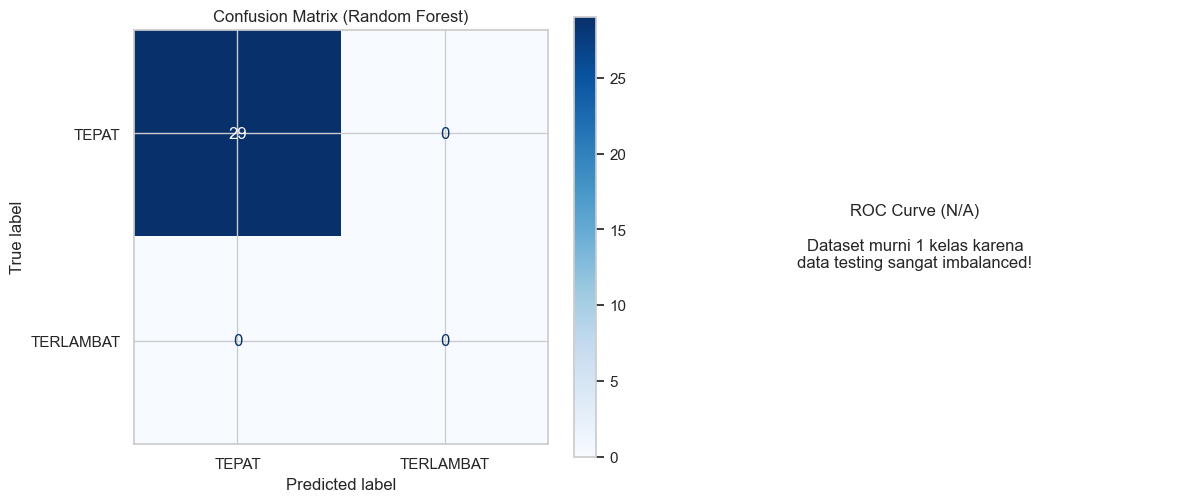

In [79]:
best_pipe = pipelines[best_model_name]

# Prediksi untuk Visualisasi
y_pred_vis = best_pipe.predict(X_test)
y_prob_vis = best_pipe.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Memaksa confusion matrix untuk membaca semua label yang ada
classes_list = range(len(target_le.classes_))

ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_vis, 
    labels=classes_list,
    display_labels=target_le.classes_, 
    cmap='Blues', 
    ax=ax[0]
)
ax[0].set_title(f'Confusion Matrix ({best_model_name})')

# Cek apakah Test Set berisi > 1 kelas (ROC hanya bisa digambar jika ada 2 kelas)
n_classes_in_test = len(np.unique(y_test))

if n_classes_in_test > 1:
    try:
        RocCurveDisplay.from_predictions(y_test, y_prob_vis, ax=ax[1])
        ax[1].set_title(f'ROC Curve ({best_model_name})')
    except Exception as e:
        ax[1].text(0.5, 0.5, f'ROC Plot Error:\n{e}', ha='center', va='center', wrap=True)
else:
    ax[1].text(0.5, 0.5, 'ROC Curve (N/A)\n\nDataset murni 1 kelas karena\ndata testing sangat imbalanced!', 
               ha='center', va='center', wrap=True)
    ax[1].set_axis_off()
    print("WARNING: Test set hanya memiliki 1 kelas. Evaluasi ROC Curve tidak dapat dilakukan pada split ini.")

plt.tight_layout()
plt.show()


### B. Visualisasi Decision Boundary
Karena data kita memiliki banyak dimensi (banyak kolom), kita gunakan **PCA (Principal Component Analysis)** untuk merangkum semua fitur menjadi 2 dimensi (PCA 1 dan PCA 2). Setelah itu, kita latih ulang model di data 2D tersebut dengan **SMOTE** untuk melihat bagaimana model membuat garis batas keputusan (*Decision Boundary*). SMOTE akan membuat decision boundary tidak dominan 1 warna saja.


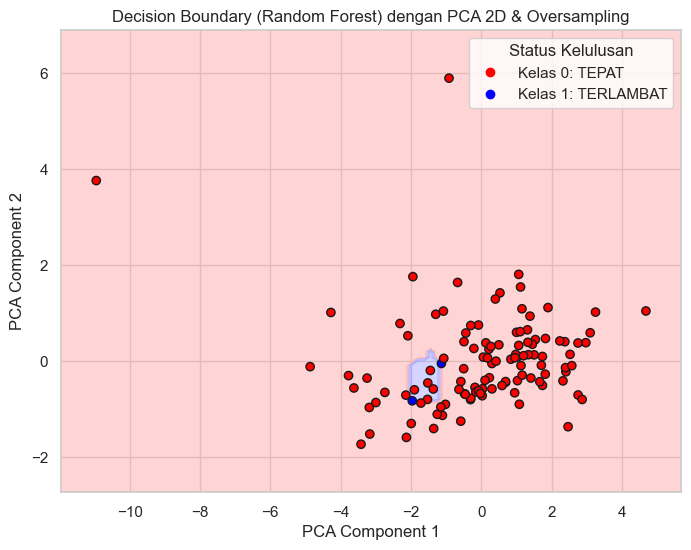

In [80]:
# Ekstrak data hasil preprocessing (semua fitur jadi angka)
X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_trans)
X_test_pca = pca.transform(X_test_trans)

# Latih ulang model terbaik HANYA dengan 2 komponen PCA + Dinamik Sampler
clf_2d = ImbPipeline(steps=[
    ('sampler', clone(sampler)),
    ('classifier', clone(models[best_model_name]))
])
clf_2d.fit(X_train_pca, y_train)

fig, ax = plt.subplots(figsize=(8, 6))

# Define kustom colormaps agar kompatibel dengan versi Scikit-Learn lama & baru
# (Menghindari error multiclass_colors_)
cmap_light = mpl.colors.ListedColormap(['#FFAAAA', '#AAAAFF'])
cmap_bold = mpl.colors.ListedColormap(['#FF0000', '#0000FF'])

disp = DecisionBoundaryDisplay.from_estimator(
    clf_2d, X_train_pca, response_method="predict",
    xlabel="PCA Component 1", ylabel="PCA Component 2",
    alpha=0.5, ax=ax, cmap=cmap_light
)

scatter = disp.ax_.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, edgecolor="k", cmap=cmap_bold)

labels = [f"Kelas {i}: {target_le.inverse_transform([i])[0]}" for i in range(len(target_le.classes_))]
handles, _ = scatter.legend_elements()
ax.legend(handles, labels, loc="best", title="Status Kelulusan")

plt.title(f'Decision Boundary ({best_model_name}) dengan PCA 2D & Oversampling')
plt.show()


### C. Cek Feature Importance
Menampilkan pentingnya setiap kolom untuk ke-3 model dasar (RF, XGB, GB) agar bisa dianalisis fitur mana yang paling menentukan kelulusan.


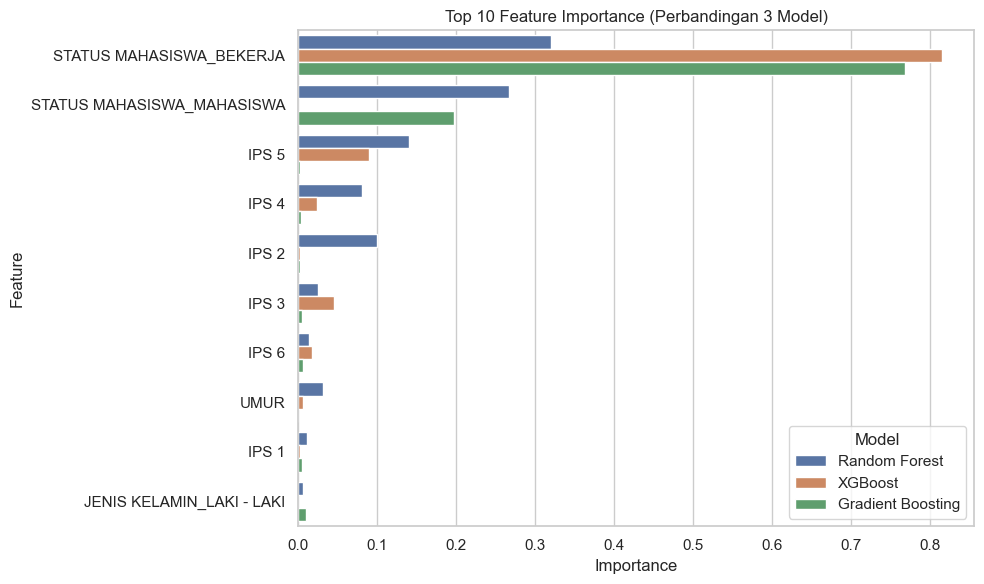

In [81]:
preproc = pipelines['Random Forest'].named_steps['preprocessor']
feat_num = num_cols

try:
    feat_cat = preproc.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols)
    feat_names = list(feat_num) + list(feat_cat)
except Exception as e:
    feat_names = [f"Feature_{i}" for i in range(X_train_trans.shape[1])]

fi_data = {'Feature': feat_names}
for name in ['Random Forest', 'XGBoost', 'Gradient Boosting']:
    model = pipelines[name].named_steps['classifier']
    importances = model.feature_importances_
    if len(importances) == len(feat_names):
        fi_data[name] = importances

df_fi = pd.DataFrame(fi_data)
df_fi['Average Importance'] = df_fi[['Random Forest', 'XGBoost', 'Gradient Boosting']].mean(axis=1)
df_fi = df_fi.sort_values(by='Average Importance', ascending=False).head(10)

df_fi_melt = df_fi.melt(id_vars='Feature', value_vars=['Random Forest', 'XGBoost', 'Gradient Boosting'], var_name='Model', value_name='Importance')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_fi_melt, x='Importance', y='Feature', hue='Model')
plt.title('Top 10 Feature Importance (Perbandingan 3 Model)')
plt.tight_layout()
plt.show()


## 6. Deployment
Menyimpan pipeline dari model terpilih (Paling Robust) ke `model_kelulusan_robust.pkl`.


In [82]:
MODEL_PATH = 'model_kelulusan_robust.pkl'
best_pipeline = pipelines[best_model_name]
joblib.dump(best_pipeline, MODEL_PATH)
print(f"Model {best_model_name} berhasil disimpan di: {MODEL_PATH}")


Model Random Forest berhasil disimpan di: model_kelulusan_robust.pkl
